# Load and analyse wildfire data

In [83]:
# import 

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot
import os
import matplotlib.ticker as ticker
import numpy as np
import xarray as xr
import sys
from utils.utilities import find_best_grid_point, get_station_coords,form_xdate, get_anomalies
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime as dt
import mplotutils as mpu
from utils import process_data


from plotting import tol_colors # color schemes from https://personal.sron.nl/~pault/

#activate interactive figures
#%matplotlib widget
#activate autoreload
%load_ext autoreload

## Add parent directory to syspath
parent_dir = os.path.abspath(os.path.join(os.path.dirname('.'), '..'))
if not parent_dir in sys.path:
    sys.path.append(parent_dir)

#directory for figure saving
#dir_save = './output/fire_activity/' 
dir_save = './output/fire_activity/' 

# Save figure or not
save_fig = True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### First, read all our measurement data (GHG) for comparison

In [51]:
## Read all data
%autoreload 2
from analyses.input.read_wdc_data import AvailableData, create_data_reader

# File path
data_path = "../data/"

# if New data is added to ./data folder, adapt the dictionary in AvailableData
all_data = list(AvailableData)
print(all_data)

#####---------- TO ADAPT ---------------#####
selected_data = ['CO2', 'CO2_flask', 
                 'CO', 'CO_flask', 
                 'CH4', 'CH4_flask', 
                 'O3'
                 ] # define data to read in. If empty, all data is used 
## 
processing_kwargs = { 
    'FLASK_FLAG_CORR' : True # exclude flagged flask-data
}
#####-----------------------------------#####

datasets = [] # initialize list of all datasets 
# read in data
for sel in (selected_data if selected_data else all_data):
    #define where the data has to be read from
    data_reader =  create_data_reader(data_path=data_path,dataset=sel,**processing_kwargs) #creates an instance of the desired data_reader class
    print(f"Data from {data_reader.__class__.__name__} for {sel}:")

    # call the data-reading function on that instance: 
    data = data_reader.read_data() 
    # call the data-processing
    data = data_reader.process_data(data)

    # prepare merged dataset
    data = data.drop(columns='endtime') # problem when merging datasets (because of NaT?), so better remove endtime
    ds = data.to_xarray()
    ds = ds.assign_coords(dataset=sel)
    ds['species'] = data_reader.species
    ds['unit']  = np.unique(ds.unit.dropna(dim='time'))[0]
    datasets.append(ds)

# save all in one xarray dataset
ds_all = xr.concat(datasets,dim="dataset")
ds_all

['CO2', 'CO2_flask', 'CO', 'CO_flask', 'CO_2002-2006', 'CH4', 'CH4_flask', 'O3', 'aerosols_2015', 'aerosols', 'other_gases_ebas', 'other_gases_wdc', 'meteo']
Data from wdcGHGReader for CO2:
Data from wdcFlaskReader for CO2_flask:
Data from wdcGHGReader for CO:
Data from wdcFlaskReader for CO_flask:
Data from wdcGHGReader for CH4:
Data from wdcFlaskReader for CH4_flask:
Data from ebasReader for O3:


<xarray.Dataset>
Dimensions:             (time: 114106, dataset: 7)
Coordinates:
  * time                (time) datetime64[ns] 2002-05-31T23:00:00 ... 2023-12...
  * dataset             (dataset) <U9 'CO2' 'CO2_flask' ... 'CH4_flask' 'O3'
Data variables: (12/17)
    site_gaw_id         (dataset, time) object nan nan nan nan ... nan nan nan
    value               (dataset, time) float64 nan nan nan ... 32.78 36.53
    value_unc           (dataset, time) float64 nan nan nan ... 2.32 0.7698
    nvalue              (dataset, time) float64 nan nan nan nan ... nan nan nan
    latitude            (dataset, time) float64 nan nan nan nan ... nan nan nan
    longitude           (dataset, time) float64 nan nan nan nan ... nan nan nan
    ...                  ...
    QCflag              (dataset, time) float64 nan nan nan nan ... 0.0 0.0 0.0
    instrument          (dataset, time) float64 nan nan nan nan ... nan nan nan
    measurement_method  (dataset, time) float64 nan nan nan nan ... nan nan nan
    scale               (dataset, time) float64 nan nan nan nan ... nan nan nan
    unit                (dataset) <U3 'ppm' 'ppm' 'ppb' 'ppb' 'ppb' 'ppb' 'ppb'
    species             (dataset) <U3 'CO2' 'CO2' 'CO' 'CO' 'CH4' 'CH4' 'O3'

### check GFAS fire data

In [52]:
## Read in CAMS GFAS fire data
# Read all full cams datasets
dir_data_cams = r"../data/level3/cams"
cams_gfas = xr.open_dataset(dir_data_cams + r"/cams_gfas_2020_2023.nc")

In [53]:
##Take a mean of the fire activity over the whole area
t1 = "2020-01-01"
t2 = "2023-12-31"
gfas_mean = cams_gfas.mean(dim="latitude").mean(dim="longitude").sel(time=slice(t1, t2))

# define which measurement I would like to plot
obs_var = "CO"

In [54]:
## select a more local fire activity mean

mknlat, mknlon, mknalt = get_station_coords("MKN")  # Mt. Kenya station coordinates

# define a "local" area
dlat = 10  # lat difference to station
dlon = 10 # lon difference to station
[lat_min, lat_max, lon_min, lon_max] = [
    mknlat - dlat,
    mknlat + dlat,
    mknlon - dlon,
    mknlon + dlon,
]

gfas_mean_local = (
    cams_gfas.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))
    .mean(dim="latitude")
    .mean(dim="longitude")
    .sel(time=slice(t1, t2))
)

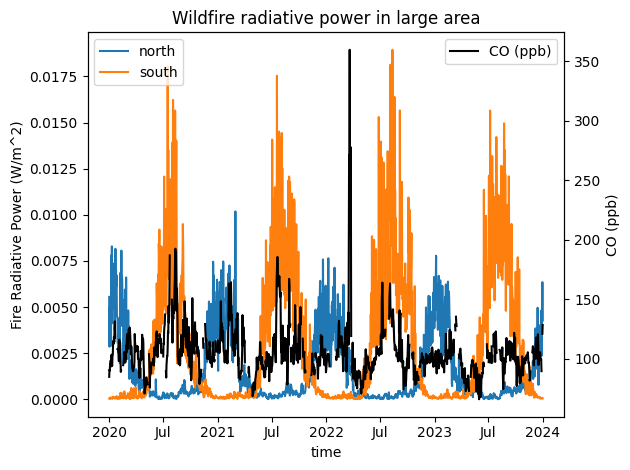

In [55]:
## plot the fireactivity as a time series
# If desired, distinguish between north and south of MKN station

fig, ax = plt.subplots(1, 1)
t1 = "2020-01-01"
t2 = "2023-12-31"

# gfas_mean["frpfire"].plot(label="Total mean fire activity", color="C1")
# gfas_mean_local["frpfire"].plot(label=f"Local fire activity (+/-{dlat}°lat/{dlon}°lon)", color="C3", ls=":")

# to distinguish between north and south:
cams_gfas.where(cams_gfas.latitude > mknlat).mean(dim='latitude').mean(dim='longitude').sel(time=slice(t1,t2))['frpfire'].plot(label='north')
cams_gfas.where(cams_gfas.latitude < mknlat).mean(dim='latitude').mean(dim='longitude').sel(time=slice(t1,t2))['frpfire'].plot(label='south')
ax.set_ylabel("Fire Radiative Power (W/m^2)")
ax2 = ax.twinx()

## plot measurement data
ds_all.sel(dataset=obs_var)["value"].sel(time=slice(t1, t2)).resample(
    time="1D"
).mean().plot(ax=ax2, label="CO (ppb)", color="k")
# ax2.set_ylim([50,300])
ax2.set_ylabel(obs_var)
# cams_gfas.mean(dim='latitude').mean(dim='longitude')['cofire'].sel(time=slice(t1,t2)).plot(ax=ax2,color='red') #cams CO (not working?)
plt.title("Wildfire radiative power in large area")
plt.tight_layout()
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
ax2.set_ylabel('CO (ppb)')
plt.savefig(
    f"{dir_save}timeseries_firec_co_local_{dlat*2}x{dlon*2}deg.png", dpi=400
)
plt.savefig(f"{dir_save}timeseries_firec_co_NS.png", dpi=400)
plt.show()

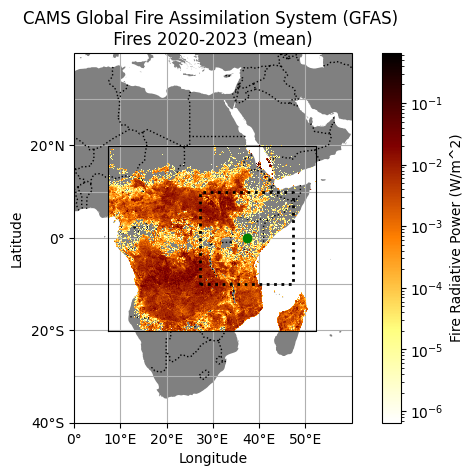

In [56]:
from matplotlib.colors import LogNorm, SymLogNorm
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

## Show a map with all fire activity for a specific period

t1 = "2020-01-01"
t2 = "2023-12-31"

gfas_sel = cams_gfas["frpfire"].sel(time=slice(t1, t2)).mean(dim="time")
# only more local fires:
# gfas_sel = cams_gfas.sel(latitude=slice(lat_max,lat_min), longitude = slice(lon_min,lon_max))["frpfire"].sel(time=slice(t1, t2)).mean(dim="time")
gfas_sel = gfas_sel.where(
    gfas_sel != 0, other=np.nan
)  # only plot non-zero values, set all others to nan

# area to map
[lon1, lon2, lat1, lat2] = [0, 60, -40, 40]

# start the figure
projection = ccrs.PlateCarree() # ccrs.Orthographic(central_latitude=40)
fig,ax = plt.subplots(1,1,subplot_kw=dict(projection=projection))
ax.set_extent([lon1, lon2, lat1, lat2], crs=projection)

lands = cfeature.NaturalEarthFeature(
    category="physical", name="land", scale="50m"
)  # cfeature.COLORS['land']
ax.add_feature(lands, zorder=0, facecolor="grey")
ax.add_feature(cfeature.BORDERS, linestyle=":", edgecolor="black")
# ax.add_feature(cfeature.LAKES)
# ax.add_feature(cfeature.RIVERS)

# waters = cfeature.NaturalEarthFeature(category='physical', name='rivers_lake_centerlines',scale= '50m')
# ax.add_feature(waters)

pl = gfas_sel.plot(
    cmap="afmhot_r",
    norm=LogNorm(),
    transform=ccrs.PlateCarree(),
    #add_colorbar = False, #add it later
    cbar_kwargs={"label": "Fire Radiative Power (W/m^2)"},
    rasterized=True,
    zorder=3,
    ax=ax
)

# or: do the log manually for the map:
# plt.pcolormesh(gfas_sel["longitude"],gfas_sel["latitude"],-np.log10(gfas_sel),cmap="hot",transform=ccrs.PlateCarree())
# cbar = plt.colorbar(label="-log(Fire Radiative Power [W/m^2])")
# cbar.set_ticks(np.arange(np.floor(np.min(ds_toplot)), np.ceil(np.max(ds_toplot)) + 1))

# adapt the colorbar
#cbar = mpu.colorbar(pl, ax,orientation='vertical') #requires add_colorbar=False before, but not working yet?
#cbar.set_label("Fire Radiative Power (W/m^2)")

mknlat, mknlon, mknalt = get_station_coords("MKN")
ax.plot(
    mknlon, mknlat, marker="o", color="g", transform=ccrs.PlateCarree(), zorder=5
)  # mt. kenya station

# define the plotting of a rectangle
def plot_rect(ax, lat_min, lat_max, lon_min, lon_max, color="C3",ls='-',lw=2):
    pl = ax.plot(
        [lon_min, lon_max, lon_max, lon_min, lon_min],
        [lat_min, lat_min, lat_max, lat_max, lat_min],
        transform=ccrs.PlateCarree(),
        color=color,
        linestyle=ls,
        linewidth=lw,
        zorder=4,
    )
    return ax, pl

# Add a rectangle to show the available gfas area
gfas_lat_min, gfas_lat_max = [gfas_sel.latitude.min(), gfas_sel.latitude.max()]
gfas_lon_min, gfas_lon_max = [gfas_sel.longitude.min(), gfas_sel.longitude.max()]
plot_rect(ax, gfas_lat_min, gfas_lat_max, gfas_lon_min, gfas_lon_max, color="k",lw=0.8)

# Add a rectangle to show the local area
plot_rect(ax, lat_min, lat_max, lon_min, lon_max, color="k",ls=':')


# set the ticks
ax.set_xticks(np.arange(lon1, lon2, 10), crs=projection)
ax.set_yticks(np.arange(lat1, lat2, 20), crs=projection)

# format the ticks
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.gridlines(zorder=1, linestyle="-")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")


#plt.draw()
mpu.set_map_layout(ax, width=20) #set nicer map layout

ax.set_title("CAMS Global Fire Assimilation System (GFAS) \n Fires 2020-2023 (mean) ")
if save_fig:
    plt.savefig(f"{dir_save}fireactivity_map_local_{dlat*2}x{dlon*2}deg.png", dpi=400)
plt.show()

In [70]:
from cartopy.feature import ShapelyFeature
from cartopy.io.shapereader import Reader,natural_earth

# Function to plot towns with names on a map
def plot_towns(
    ax, lats, lons, resolution="10m", transform=ccrs.PlateCarree(), zorder=3
):
    """
    This function will download the 'populated_places' shapefile from
    NaturalEarth, trim the shapefile based on the limits of the provided
    lat & long coords, and then plot the locations and names of the towns
    on a given GeoAxes.

    ax = a pyplot axes object
    lats = latitudes
    lons = longitudes
    resolution= str. either high res:'10m' or low res: '50m'
    transform = a cartopy crs object

    From https://gist.github.com/cbur24/9122c763301f6de1d6e1fc39763c2444
    """
    # get town locations
    shp_fn = natural_earth(
        resolution=resolution, category="cultural", name="populated_places"
    )
    shp = Reader(shp_fn)
    xy = [pt.coords[0] for pt in shp.geometries()]
    x, y = list(zip(*xy))

    # get town names
    towns = shp.records()
    names_en = []
    for town in towns:
        names = town.attributes["NAME"]
        names_en.append(names)

    # create data frame and index by the region of the plot
    all_towns = pd.DataFrame({"names_en": names_en, "x": x, "y": y})
    region_towns = all_towns[
        (all_towns.y < np.max(lats))
        & (all_towns.y > np.min(lats))
        & (all_towns.x > np.min(lons))
        & (all_towns.x < np.max(lons))
    ]

    # plot the locations and labels of the towns in the region
    ax.scatter(
        region_towns.x.values,
        region_towns.y.values,
        c="dimgrey",
        marker=".",
        transform=transform,
        zorder=zorder,
    )
    transform_mpl = ccrs.PlateCarree()._as_mpl_transform(
        ax
    )  # this is a work-around to transform xy coords in ax.annotate
    for i, txt in enumerate(region_towns.names_en):
        ax.annotate(
            txt,
            (region_towns.x.values[i], region_towns.y.values[i]),
            xycoords=transform_mpl,
            textcoords="offset points",
            xytext=(3, 3), #text offset in points
            color='dimgrey',
            fontsize='x-small'
        )

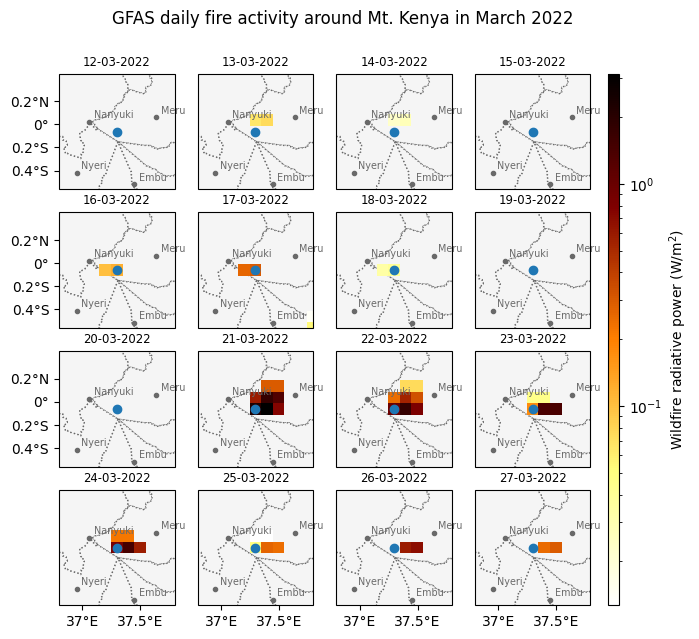

In [92]:
## Plot fire activity in a given area for selected dates

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import mplotutils as mpu

d1 = "2022-03-12"
d2 = "2022-03-27"
# d1 = "2021-03-20"
# d2 = "2021-03-28"
len_days = len(pd.date_range(start=d1, end=d2))
nrows = 4  # nbr of rows
#ncols = 5
var = "frpfire"
# area to map
dx = 0.5  # in degrees
dy = 0.5
[lon1, lon2, lat1, lat2] = [mknlon - dx, mknlon + dx, mknlat - dy, mknlat + dy]
ds_sel = cams_gfas.sel(
    time=slice(d1, d2), latitude=slice(lat2, lat1), longitude=slice(lon1, lon2)
)
ds_sel = ds_sel.where(
    ds_sel != 0, other=np.nan
)  # only plot non-zero values, set all others to nan

projection = ccrs.PlateCarree()  # ccrs.Orthographic(central_latitude=40)

fig, axs = plt.subplots(
    nrows,
    int(len_days / nrows),
    subplot_kw=dict(projection=projection),
    sharex=True,
    sharey=True,
)  # , figsize=(8, 8))
axs = axs.flatten()
vmin = ds_sel[var].min()
vmax = ds_sel[var].max()


for ii, (d, ax) in enumerate(zip(pd.date_range(start=d1, end=d2), axs)):
    ax.set_extent([lon1, lon2, lat1, lat2], crs=projection)

    # lands = cfeature.NaturalEarthFeature(category='physical', name='land',scale= '50m',
    #                                     edgecolor='black',facecolor=None) #edgecolor=frontcol,facecolor=landcol
    # countries = cfeature.NaturalEarthFeature('cultural','admin_0_countries','50m')
    # ax.add_feature(countries, linestyle=":", edgecolor="black",facecolor=None)
    # ax.add_feature(lands, zorder=0, facecolor=None)
    # ax.add_feature(cfeature.BORDERS, linestyle=":", edgecolor="black",scale= '50m',)
    # waters = cfeature.NaturalEarthFeature(category='physical', name='rivers_lake_centerlines',scale= '50m')
    # ax.add_feature(waters)
    # ax.add_feature(cfeature.LAKES)
    # ax.add_feature(cfeature.RIVERS,scale= '50m')

    # Add Kenya county borders
    filename = r".\plotting\kenyan-counties\County.shp"
    shape_feature = ShapelyFeature(
        Reader(filename).geometries(),
        ccrs.PlateCarree(),
        linewidth=1,
        facecolor="whitesmoke",
        edgecolor="dimgrey",
        linestyle=":",
    )
    ax.add_feature(shape_feature)

    im = ds_sel.sel(time=d)[var].plot(
        cmap="afmhot_r",
        norm=LogNorm(),
        transform=ccrs.PlateCarree(),
        rasterized=True,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
        zorder=2,
    )

    # plot town locations
    lons = np.arange(lon1, lon2, 0.1)
    lats = np.arange(lat1, lat2, 0.1)
    plot_towns(ax, lats, lons)

    ax.plot(mknlon, mknlat, marker="o", color="C0",label='Mt. Kenya')  # mt. kenya station
    # write Mt. Kenya label
    # ax.annotate(
    #     "Mt. Kenya",
    #     (mknlon, mknlat),
    #     xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
    #     textcoords="offset points",
    #     xytext=(3, -4),  # text offset in points
    #     color="C0",
    #     verticalalignment="top",
    #     horizontalalignment="left",
    #     # backgroundcolor = 'white',
    #     # alpha=0.5
    # )

    # no axes labels
    ax.set_ylabel("")
    ax.set_xlabel("")

    ### Ticks and labels
    if ii in [0, len_days / nrows, (len_days / nrows) * 2]:  # only first column
        # set the yticks
        ax.set_yticks(np.arange(round(lat1, 1), round(lat2, 1), 0.2), crs=projection)
        ax.yaxis.set_major_formatter(LatitudeFormatter())
    if ii > (len_days / nrows * (nrows-1))-1:  # only lowest row
        ax.set_xticks(np.arange(round(lon1), round(lon2), 0.5), crs=projection)
        # format the ticks
        ax.xaxis.set_major_formatter(LongitudeFormatter())
        # ax.gridlines(zorder=1, linestyle="-")

    # no axes labels
    ax.set_ylabel("")
    ax.set_xlabel("")
    # axis title:
    month_str = dt.datetime.strptime(str(d.month), "%m").strftime("%B")
    ax.set_title(f"{d.day}-{d.month:02d}-{d.year}", fontsize="small")

cbar = mpu.colorbar(
    im,
    ax=[axs[int(len_days / nrows)-1], axs[-1]],
    pad=0.15,
    size=0.1,
    orientation="vertical",
    label="Wildfire radiative power (W/m$^2$)",
)

# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")
fig.subplots_adjust(
    hspace=0.2, wspace=0.2, left=0.1, right=0.85, bottom=0.05, top=0.88
)  # manually adjust spaces to have no cutoff when saving
mpu.set_map_layout(axs, width=18)

plt.suptitle(f"GFAS daily fire activity around Mt. Kenya in {month_str} {d.year}")

if save_fig:
    plt.savefig(f"{dir_save}fireevent_gfas_MKN_{d.month:02d}{d.year}.png", dpi=400)
plt.show()

In [101]:

fire_dates_Mar2022 = slice('2022-03-13','2022-03-27')
fire_times_Mar2022 = ds_all.sel(time=fire_dates_Mar2022).time.values

fire_dates_Mar2021 = slice('2021-03-20','2021-03-28')
fire_times_Mar2021 = ds_all.sel(time=fire_dates_Mar2021).time.values

remove_fire_events=True
remove_outliers=False

if remove_fire_events:
    ds_all_rem_out = ds_all.where(ds_all.time.isin(fire_times_Mar2022)==False) #don't use the fire event times 2022
    ds_all_rem_out = ds_all.where(ds_all.time.isin(fire_times_Mar2021)==False) #don't use the fire event times 2021

if remove_outliers:
    # Remove outliers that exceed 10*stdedeviation_mean and 4* the zscore 
    # remove outliers for each species sperarately
    ds_all_rem_out = ds_all.copy(deep=True) #use deepcopy, otherwise it replaces values in ds_all!
    outlier_masks = {}
    for ds in np.unique(ds_all.species):
        print(f"remove outliers for {ds}:")
        ds_all_rem_out.loc[dict(dataset=ds)], mask_removed_outliers= process_data.rem_out(ds_all.sel(dataset=ds), std_fac=10, z_threshold=4)
        outlier_masks[ds] = mask_removed_outliers
# ## plot removed data
# var = "value"

# #remove CO outliesr
# s = 'CO'

# f, axs = plt.subplots(2, 1, sharex=True)
# plt.suptitle("Removed outliers")
# ds_all.sel(dataset=s)[var].plot(ls="", marker="o", ax=axs[0])
# ds_all.sel(dataset=s)[var + "_unc"].plot(ls="", marker="o", ax=axs[1])
# # new data:
# ds_all_rem_out.sel(dataset=s)[var].plot(ls="", marker=".", ax=axs[0])
# ds_all_rem_out.sel(dataset=s)[var + "_unc"].plot(ls="", marker=".", ax=axs[1])
# plt.show()

### Do some scatterplots fireactivity vs. CO

C:\Users\leob\AppData\Local\Temp\ipykernel_23608\4249475206.py:76: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(x_month, y_month, alpha=1, c=colors[month - 1])


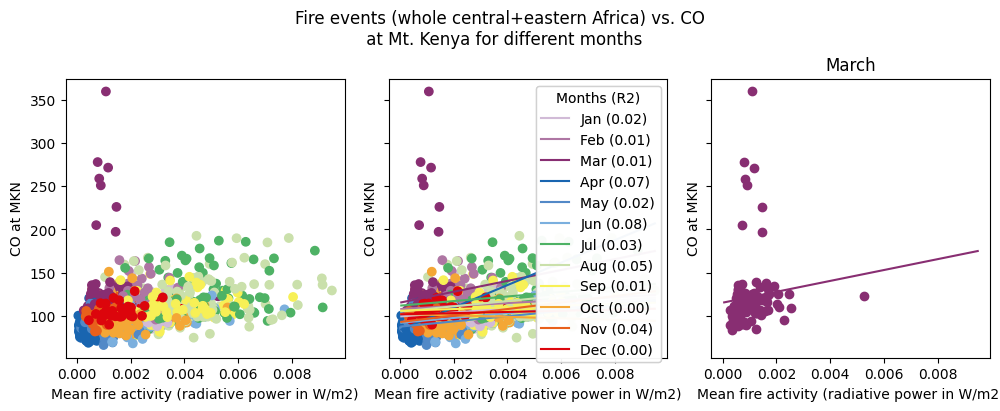

In [93]:
from sklearn.linear_model import LinearRegression

## Mean fire vs. CO for different months


# x = cams_gfas.sel(time=slice(t1, t2)).mean(dim=["latitude", "longitude"])["frpfire"]
x = gfas_mean["frpfire"]
# ,latitude=slice(5,-5),longitude=slice(32,42)
y = ds_all.sel(dataset=obs_var, time=slice(t1, t2))["value"].resample(time="D").mean()
#y = ds_all_rem_out.sel(dataset=obs_var, time=slice(t1, t2))["value"].resample(time="D").mean() #removed outliers
months = x.time.dt.month

# Define a colormap for months
colmap = tol_colors.tol_cmap("rainbow_discrete", 12)  # 12 colors for 12 months
colors = colmap(np.linspace(0, 1, 12))

fig, axs = plt.subplots(
    1, 3, figsize=(10, 4), sharey=True, sharex=True, layout="constrained"
)
for i, ax in enumerate(axs):
    # first subplot: all months scatter
    if i == 0:
        scatter = ax.scatter(x, y, c=months, cmap=colmap, alpha=1)
        # legend1 = ax.legend(
        #     *scatter.legend_elements(), loc="upper right", title="Months"
        # )
        # ax.add_artist(legend1)

    # second subplot: all months scatter with linear fits
    elif i == 1:
        scatter = ax.scatter(x, y, c=months, cmap=colmap, alpha=1)
        # legend1 = ax.legend(*scatter.legend_elements(), loc="upper right", title="Months")
        # ax.add_artist(legend1)
        ## add line fits:
        # Iterate over unique months and fit a line for each month
        for month, c in zip(range(1, 13), colors):
            # Filter data for the current month
            x_month = x.where(x.time.dt.month == month, drop=True)
            y_month = y.where(y.time.dt.month == month, drop=True)

            # CO data contains some nans, remove them to be able to make a fit
            y_month_non_nan = y_month.dropna(dim="time")
            x_month_non_nan = x_month.sel(time=y_month_non_nan.time.values, drop=True)

            if len(x_month) > 1:
                # Fit a linear regression model
                model = LinearRegression()
                model.fit(x_month_non_nan.values.reshape(-1, 1), y_month_non_nan.values)

                # Predictions
                x_pred = np.linspace(
                    x.min(), x.max(), 2
                )  # create x-values for which to predict y-values
                y_pred = model.predict(x_pred.reshape(-1, 1))

                # Plot the line fit for the current month
                r2 = model.score(x_month_non_nan.values.reshape(-1, 1), y_month_non_nan.values)
                month_str = dt.datetime.strptime(str(month), "%m").strftime("%b")
                ax.plot(
                    x_pred, y_pred, color=c, label=f"{month_str} ({r2:.2f})"
                )  # color=colmap(month / 13)
                # ax.plot(x_pred, y_pred, color=colmap(month / 13), label=f'Month {month}')
            else:
                print(f"no fit for month {month}")
            legend1 = ax.legend(
                loc="upper right", title="Months (R2)"
        )
        ax.add_artist(legend1)

    # 3rd subplot: only single month
    elif i == 2:
        month = 3  ## Select a specific month
        x_month = x.where(x.time.dt.month == month, drop=True)
        y_month = y.where(y.time.dt.month == month, drop=True)

        scatter = ax.scatter(x_month, y_month, alpha=1, c=colors[month - 1])
        dt.datetime.strptime("1", "%m").strftime("%b")
        str_mon = dt.datetime.strptime(str(month), "%m").strftime("%B")
        ax.set_title(str_mon)

        # Fit a linear regression model
        # CO data contains some nans, remove them to be able to make a fit
        y_month_non_nan = y_month.dropna(dim="time")
        x_month_non_nan = x_month.sel(time=y_month_non_nan.time.values, drop=True)
        if len(x_month) > 1:
            model = LinearRegression()
            model.fit(x_month_non_nan.values.reshape(-1, 1), y_month_non_nan.values)

            # Predictions
            x_pred = np.linspace(
                x.min(), x.max(), 10
            )  # using x (instead of x_month) to have same x values as for all months
            y_pred = model.predict(x_pred.reshape(-1, 1))

            # Plot the line fit for the current month
            ax.plot(x_pred, y_pred, color=colors[month - 1], label=f"Month {month}")

    ax.set_ylabel(f"{obs_var} at MKN")
    ax.set_xlabel("Mean fire activity (radiative power in W/m2)")

# general figure properties
plt.setp(axs, box_aspect=1)  # get quadratic plots

plt.suptitle(
    "Fire events (whole central+eastern Africa) vs. CO \n at Mt. Kenya for different months"
)
if save_fig:
    plt.savefig(f"{dir_save}scatter_plots_fire_{obs_var}.pdf")
plt.show()

In [94]:
# make a pandas dataframe to use it in seaborn
df = pd.concat([x.to_dataframe(), y.to_dataframe()])
df.rename(columns={"value": "CO"}, inplace=True)  # rename CO column
df.drop("dataset", axis="columns", inplace=True)  # remove unnecessary column
df["months"] = df.index.month
df.head()

,frpfire,CO,months
time,,,
2020-01-01,0.002789,NaN,1
2020-01-02,0.001442,NaN,1
2020-01-03,0.002522,NaN,1
2020-01-04,0.001719,NaN,1
2020-01-05,0.002028,NaN,1


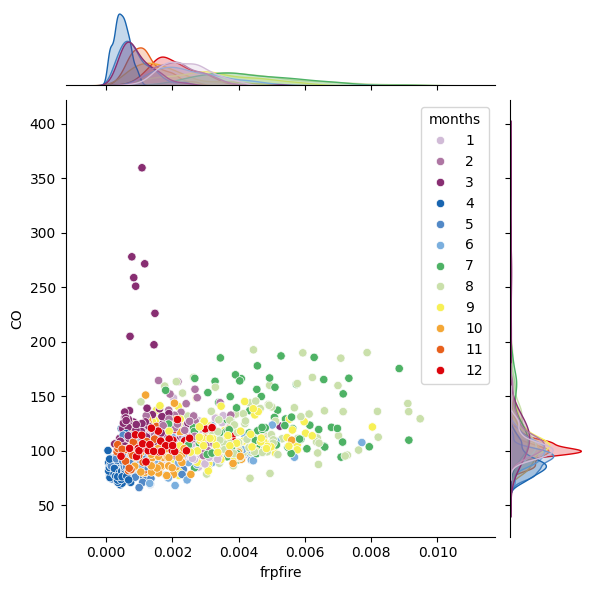

In [95]:
## try a jointplot with seaborn
import seaborn as sns


# Define a colormap for months
colmap = tol_colors.tol_cmap("rainbow_discrete", 12)  # 12 colors for 12 months
colors = colmap(np.linspace(0, 1, 12))

sns.jointplot(df, x="frpfire", y="CO", hue="months", palette=colmap, legend="full")

# sns.jointplot(x=x, y=y, hue=months, palette=colmap, legend="full")  # using x and y instead of dataframe

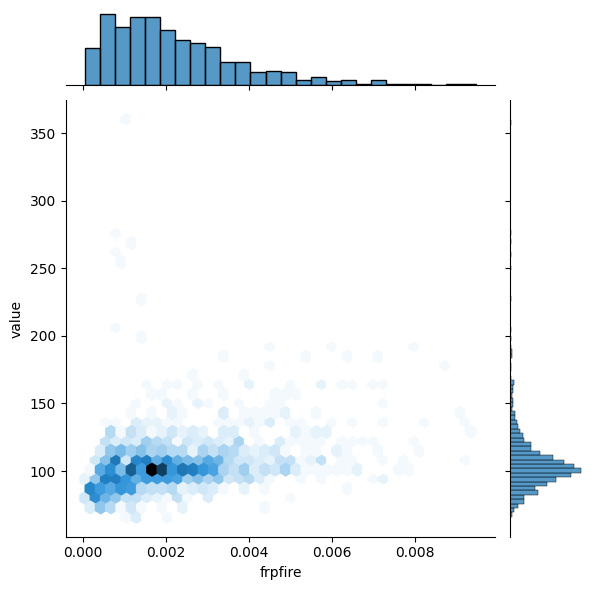

In [96]:
## check all months
sns.jointplot(
    # x=x, y=y, hue=months, palette=colmap, legend="full"
    x=x,
    y=y,
    kind="hex",
)

In [97]:
## distinguish fire events north and south of mount kenya station
gfas_north = cams_gfas.where(cams_gfas.latitude > mknlat)
gfas_south = cams_gfas.where(cams_gfas.latitude < mknlat)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


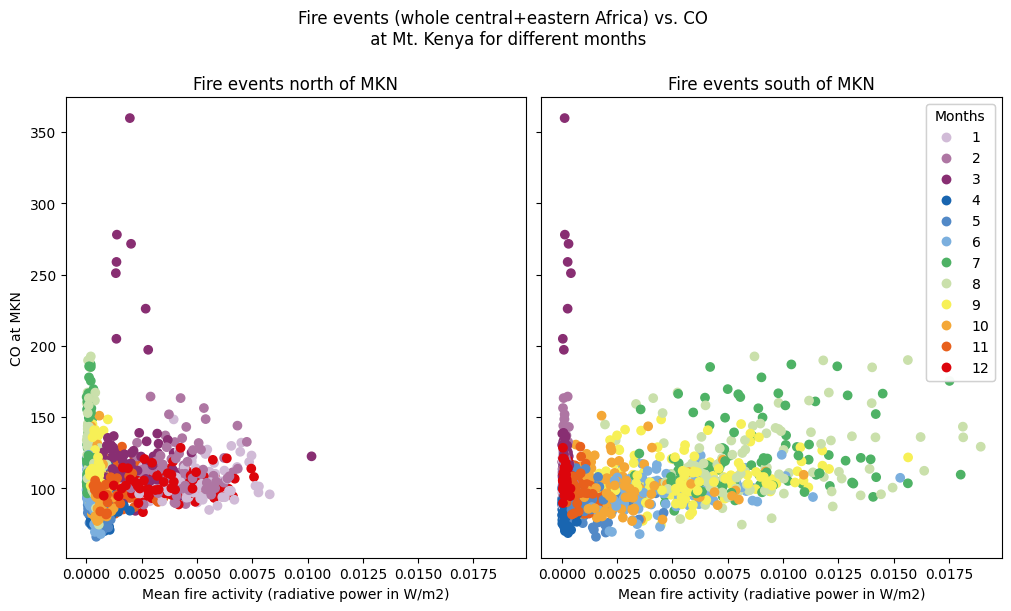

In [98]:
# same (fire activity vs. CO) but for north and south from MKN station

mknlat, mknlon, mknalt = get_station_coords("MKN")


# TO ADAPT

line_fit = False


fig, axs = plt.subplots(
    1, 2, figsize=(10, 6), sharey=True, sharex=True, layout="constrained"
)

## devide in different latitude regions (above and below the station)

for i, ax in enumerate(axs):

    y = ds_all.sel(dataset="CO", time=slice(t1, t2))["value"].resample(time="D").mean()

    # select fires above or below the station

    if i == 0:

        gfas_sel = gfas_north

        tit = "Fire events north of MKN"

    else:

        gfas_sel = gfas_south

        tit = "Fire events south of MKN"

    x = gfas_sel.sel(time=slice(t1, t2)).mean(dim=["latitude", "longitude"])["frpfire"]
    months = x.time.dt.month

    # Define a colormap for months

    colmap = tol_colors.tol_cmap("rainbow_discrete", 12)  # 12 colors for 12 months
    scatter = ax.scatter(
        x,
        y,
        c=months,
        cmap=colmap,
    )

    ax.set_xlabel("Mean fire activity (radiative power in W/m2)")
    ax.set_title(tit)

    if line_fit:

        ## add line fits:

        # Iterate over unique months and fit a line for each month

        for month, c in zip(range(1, 13), colors):

            # Filter data for the current month

            x_month = x.where(x.time.dt.month == month, drop=True)

            y_month = y.where(y.time.dt.month == month, drop=True)

            # CO data contains some nans, remove them to be able to make a fit

            y_month_non_nan = y_month.dropna(dim="time")

            x_month_non_nan = x_month.sel(time=y_month_non_nan.time.values, drop=True)

            if len(x_month) > 1:

                # Fit a linear regression model

                model = LinearRegression()

                model.fit(x_month_non_nan.values.reshape(-1, 1), y_month_non_nan.values)

                # Predictions
                x_pred = np.linspace(
                    x.min(), x.max(), 2
                )  # create x-values for which to predict y-values

                y_pred = model.predict(x_pred.reshape(-1, 1))

                # Plot the line fit for the current month
                ax.plot(
                    x_pred, y_pred, color=c, label=f"Month {month}"
                )  # color=colmap(month / 13)

                # ax.plot(x_pred, y_pred, color=colmap(month / 13), label=f'Month {month}')

            else:

                print(f"no fit for month {month}")


plt.legend()

axs[0].set_ylabel("CO at MKN")

# plt.colorbar()

legend1 = ax.legend(*scatter.legend_elements(), loc="upper right", title="Months")

ax.add_artist(legend1)

# plt.suptitle(f"Mean regional fire events (CAMS) vs. CO at MKN between {t1} and {t2}")

# general figure properties
plt.setp(axs, box_aspect=1)  # get quadratic plots

plt.suptitle(
    "Fire events (whole central+eastern Africa) vs. CO \n at Mt. Kenya for different months"
)
if save_fig:

    plt.savefig(f"{dir_save}scatter_firec_co_NS.pdf")

    # plt.savefig('.\output\scatter_firec_co_EW.pdf')

plt.show()

In [ ]:
### Weight the fire activity with the distance to MKN station
dx = cams_gfas["longitude"] - mknlon
dy = cams_gfas["latitude"] - mknlat
dist = np.sqrt(dx**2 + dy**2)
cams_gfas["dist_mkn"] = dist
fire_weighted = cams_gfas["frpfire"] * (1 / dist)
cams_gfas["frpfire_weighted"] = fire_weighted

# TODO would need to make dist_mkn a coordinate, and make frpfire dependent on that, so that we have a dist value for each fire event!?

In [ ]:
## Check fire activity around MKN for a specific period

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

d1 = "2022-03-20"
d2 = "2022-03-28"
var = "frpfire"
ds_sel = cams_gfas.sel(time=slice(d1, d2))

fig, axs = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(8, 8))

# area to map
[lon1, lon2, lat1, lat2] = [36, 39, -1, 1]  # close zoom to MKN station

for d, ax in zip(pd.date_range(start=d1, end=d2), axs.reshape(-1)):
    vmin = ds_sel[var].min()
    vmax = ds_sel[var].max()
    im = cams_gfas.sel(time=d)[var].plot(
        ax=ax, vmin=vmin, vmax=vmax, add_colorbar=False, cmap="hot_r"
    )
    ax.plot(mknlon, mknlat, marker="x", color="g")  # mt. kenya station
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
# common colorbar
fig.colorbar(
    im,
    ax=axs.ravel().tolist(),
    orientation="vertical",
    label="Wildfire radiative power (W/m2)",
    pad=-0.5,
    # norm = LogNorm()
)
ax.set_xlim([lon1, lon2])
ax.set_ylim([lat1, lat2])
plt.tight_layout()
plt.show()

### Check Seasonal and daily cycles

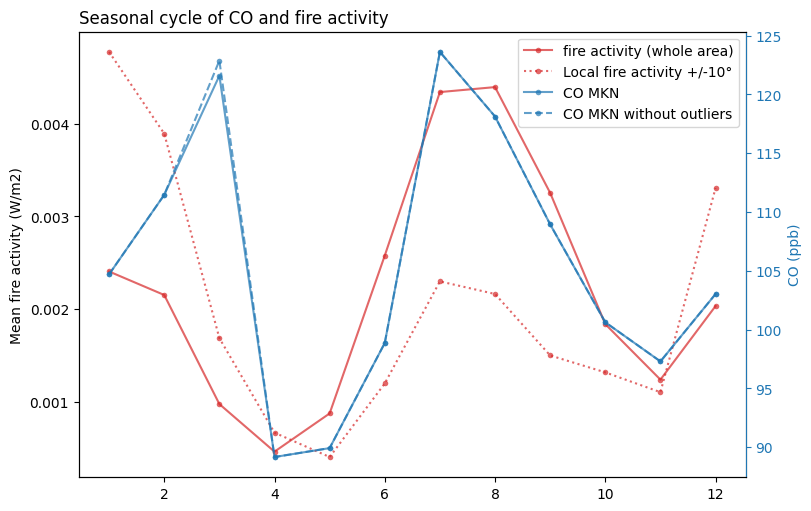

In [102]:
## plot  SEASONAL CYCLE fires (cams) versus CO observations

alpha = 0.7
ms = 8

# use cams gfas
t1 = "2020-01-01"
t2 = "2023-12-31"

species_sel = ["CO"]

# resample measurements to 1 day
meas_1D = (
    ds_all.sel(dataset=species_sel, time=slice(t1, t2))["value"]
    .resample(time="D")
    .mean()
)
meas_no_out1D = (
    ds_all_rem_out.sel(dataset=species_sel, time=slice(t1, t2))["value"]
    .resample(time="D")
    .mean()
)


freq = "month"
fig, ax = plt.subplots(1, 1, sharex=True, figsize=(8, 5),layout="constrained")


# function to plot each subplot
def plot_data(ds, ax, label, c, ls="-"):
    l = (
        ds.groupby(f"time.{freq}")
        .mean()
        .plot(
            ax=ax,
            ls=ls,
            c=c,
            marker=".",
            markeredgewidth=0,
            alpha=alpha,
            markersize=ms,
            label=f"{label}",
        )
    )
    return l


# plot cams
fire_color = "C3"  # the new matplotlib default colors can be accessed with CN (N=0-9)
l1 = plot_data(
    gfas_mean.sel(time=slice(t1, t2))["frpfire"], ax, "fire activity (whole area)", fire_color #fire activity in whole area (from latitude and longitude 0    60, -40    40)
)
l3 = plot_data(
    gfas_mean_local.sel(time=slice(t1, t2))["frpfire"],
    ax,
    f"Local fire activity +/-{dlat}°",
    fire_color,
    ls=":",
)
ax.set_ylabel("Mean fire activity (W/m2)")
ax.set_title("")

# plot obs
ax2 = ax.twinx()
meas_color = "C0"
l2 = plot_data(meas_1D, ax2, "CO MKN", meas_color)
l4 = plot_data(meas_no_out1D, ax2, "CO MKN without outliers", meas_color,ls='--')
ax2.set_ylabel("CO (ppb)")
# set axes to the measurement color
ax2.yaxis.label.set_color(meas_color)
ax2.spines["right"].set_color(meas_color)
ax2.tick_params(axis="y", colors=meas_color)
ax2.set_title("")

# common legend
lns = l1 + l3 + l2 +l4
#lns = l3 + l2 +l4 #no global fire, only local
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)


# ax.set_ylabel(f"")
ax.set_xlabel("")
ax.set_title("")

if freq == "month":
    tit = "Seasonal"
elif freq == "hour":
    tit = "Diurnal"

ax.set_title(f"{tit} cycle of CO and fire activity",loc='left')
if save_fig:
    plt.savefig(f"{dir_save}seasonal_firec_co_local_{dlat*2}x{dlon*2}deg.png",dpi=500)
plt.show()